<a href="https://colab.research.google.com/github/awinarko-hue/Project_hue/blob/main/OnWork/Graph_Spectrum_Intelligence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛰️ Graph-Based Spectrum Intelligence
### Pipeline: `NonC.csv` → Entity Resolution → Station Graph → Feature Engineering → GraphSAGE/GAT → Link/Station Anomaly → GIS

Notebook ini membangun sistem **spectrum intelligence berbasis graph** dari data perizinan frekuensi non-cellular (`NonC.csv`) yang berisi data stasiun **Land Mobile, Fixed Service (P-P microwave link), Broadcast, Aeronautical**, dll.

**Ide inti:**
- Banyak baris pada `NonC.csv` adalah *emisi/kanal frekuensi* dari stasiun fisik yang sama (koordinat sama, klien sama) → perlu **Entity Resolution** agar 1 node graph = 1 stasiun fisik.
- Antar stasiun dibentuk **edge** dari dua sumber:
  1. **Link eksplisit** (Fixed Service P-P) via `LINK_ID` / `TO_SITE_ID` — pasangan pemancar-penerima microwave.
  2. **Potensi interferensi** (co-channel/adjacent-channel) antar stasiun sejenis yang berdekatan secara geografis dan frekuensinya berdekatan.
- Di atas graph ini, **GNN (GraphSAGE / GAT)** dilatih secara *unsupervised* (Graph Autoencoder) untuk mempelajari representasi topologi+spektral tiap stasiun.
- **Anomaly score** dihitung dari reconstruction error embedding — stasiun/link yang "aneh" (misalnya ERP tidak wajar, frekuensi menyimpang dari kelompok tetangganya, atau topologi link tidak biasa) akan mendapat skor tinggi.
- Hasil akhirnya divisualisasikan di **peta GIS interaktif (folium)** untuk mendukung kerja monitoring Balmon.

> ⚠️ Catatan: threshold jarak/frekuensi di bawah adalah **parameter yang bisa disesuaikan** — silakan kalibrasi ulang sesuai kebijakan teknis (mis. Kepmen Komdigi terkait kanalisasi) dan pengetahuan domain Anda.


## 0. Setup Environment (Google Colab)

In [ ]:
# Jalankan sekali di awal sesi Colab
!pip -q install torch_geometric --extra-index-url https://data.pyg.org/whl/torch-2.4.0+cu121.html 2>/dev/null || pip -q install torch_geometric
!pip -q install networkx folium scikit-learn rapidfuzz haversine

import warnings
warnings.filterwarnings("ignore")
print("Setup selesai.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 12.8 MB/s eta 0:00:00
Setup selesai.


In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv, GATConv
from torch_geometric.utils import from_networkx, negative_sampling
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from haversine import haversine, Unit
import folium
from folium.plugins import MarkerCluster
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


## 1. Load Dataset `NonC.csv`

Upload `NonC.csv` ke sesi Colab (drag & drop ke panel File, atau gunakan cell upload di bawah), lalu jalankan cell berikutnya.

In [ ]:
# Opsional: upload interaktif jika belum ada file di working directory Colab
try:
    from google.colab import files
    import os
    if not os.path.exists("NonC.csv"):
        uploaded = files.upload()
except ImportError:
    pass  # bukan di Colab, lewati

df_raw = pd.read_csv("NonC.csv", low_memory=False)
print("Jumlah baris:", len(df_raw))
print("Jumlah kolom:", df_raw.shape[1])
df_raw.head(3)


Saving NonC.csv to NonC.csv
Jumlah baris: 2389
Jumlah kolom: 82


,CLNT_ID,NO_SIMF,APPL_ID,SITE_ID,CLNT_NAME,STATUS_SIMF,CORR_ADDR,AP_REQUEST_TYPE,SERVICE,SUBSERVICE,...,TO_LAT_SEC,TO_LAT_DIR_IND,TO_LONG_DEG,TO_LONG_MIN,TO_LONG_SEC,TO_LONG_DIR_IND,SA_SAT_NAME,SA_COMMENT,TGL_QUERY,UPT
0,50651,0032564,166042007,2.0,"TIME EXCELINDO, PT.",Granted,"JL.RING ROAD UTARA,CONDONG CATUR,DEPOK, SLEMAN...",N,Fixed Service,PP,...,53.8,S,110.0,22.0,58.6,E,NaN,NaN,10-AUG-26,BALMON KELAS I YOGYAKARTA
1,50651,0032564,166042007,3.0,"TIME EXCELINDO, PT.",Granted,"JL.RING ROAD UTARA,CONDONG CATUR,DEPOK, SLEMAN...",N,Fixed Service,PP,...,25.2,S,110.0,22.0,34.0,E,NaN,NaN,10-AUG-26,BALMON KELAS I YOGYAKARTA
2,50651,0032564,166042007,4.0,"TIME EXCELINDO, PT.",Granted,"JL.RING ROAD UTARA,CONDONG CATUR,DEPOK, SLEMAN...",N,Fixed Service,PP,...,4.2,S,110.0,23.0,6.8,E,NaN,NaN,10-AUG-26,BALMON KELAS I YOGYAKARTA


## 2. Data Cleaning & Preprocessing

Kolom-kolom kunci yang dipakai:
- **Identitas**: `CLNT_ID`, `SITE_ID`, `APPL_ID`, `CLNT_NAME`, `STN_NAME`
- **Lokasi**: `SID_LAT`, `SID_LONG` (desimal — dipakai sebagai koordinat utama)
- **Spektral**: `FREQ`, `FREQ_PAIR`, `BWIDTH`, `ERP_PWR_DBM`, `EMIS_CLASS_1`
- **Layanan**: `SERVICE`, `SUBSERVICE`, `TRANS_TYPE`, `STN_TYPE`, `ZONA`
- **Antena/geometri**: `HGT_ANT`, `AZIM`, `ELEV_ANGLE`
- **Link eksplisit (Fixed Service P-P)**: `LINK_ID`, `TO_SITE_ID`, `TO_CLNT_ID`, `STASIUN_LAWAN`


In [ ]:
KEY_COLS = [
    "CLNT_ID","APPL_ID","SITE_ID","CLNT_NAME","STN_NAME","STN_ADDR",
    "SID_LAT","SID_LONG","SERVICE","SUBSERVICE","TRANS_TYPE","STN_TYPE","ZONA",
    "FREQ","FREQ_PAIR","BWIDTH","ERP_PWR_DBM","EQ_PWR","GAIN","LOSS",
    "EMIS_CLASS_1","HGT_ANT","AZIM","ELEV_ANGLE",
    "LINK_ID","TO_SITE_ID","TO_CLNT_ID","STASIUN_LAWAN",
    "CITY","DISTRICT","PROVINCE","NUM_SETS",
]
df = df_raw[[c for c in KEY_COLS if c in df_raw.columns]].copy()

# Numerik
num_cols = ["SID_LAT","SID_LONG","FREQ","FREQ_PAIR","BWIDTH","ERP_PWR_DBM",
            "EQ_PWR","GAIN","LOSS","HGT_ANT","AZIM","ELEV_ANGLE","NUM_SETS"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Buang baris tanpa koordinat valid (wajib untuk graph berbasis GIS)
before = len(df)
df = df.dropna(subset=["SID_LAT","SID_LONG"]).reset_index(drop=True)
print(f"Baris dibuang (koordinat kosong): {before - len(df)}")

# Isi FREQ kosong dengan median per SERVICE (sekadar agar fitur tidak NaN)
df["FREQ"] = df.groupby("SERVICE")["FREQ"].transform(lambda s: s.fillna(s.median()))
df["FREQ"] = df["FREQ"].fillna(df["FREQ"].median())

# Kategorikal string bersih
for c in ["CLNT_NAME","STN_NAME","SERVICE","SUBSERVICE","ZONA","PROVINCE"]:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip().str.upper()

# ID unik per record (fallback jika SITE_ID kosong -> pakai APPL_ID)
df["SITE_ID_FILLED"] = df["SITE_ID"].fillna(-1).astype(int)
df["record_uid"] = df["CLNT_ID"].astype(str) + "_" + df["APPL_ID"].astype(str) + "_" + df["SITE_ID_FILLED"].astype(str)

print(df.shape)
df.head(3)


Baris dibuang (koordinat kosong): 0
(2389, 34)


,CLNT_ID,APPL_ID,SITE_ID,CLNT_NAME,STN_NAME,STN_ADDR,SID_LAT,SID_LONG,SERVICE,SUBSERVICE,...,LINK_ID,TO_SITE_ID,TO_CLNT_ID,STASIUN_LAWAN,CITY,DISTRICT,PROVINCE,NUM_SETS,SITE_ID_FILLED,record_uid
0,50651,166042007,2.0,"TIME EXCELINDO, PT.",0002/BS.IST AKPRIND 1,"""AKPRIND"", JL. KALISAHAK NO.28 KOMPLEK BALAPAN",-7.784500,110.385222,FIXED SERVICE,PP,...,769565.0,1.0,50651,0001/BS.UAD YOGYAKARTA,KOTA YOGYAKARTA,GONDOKUSUMAN,DAERAH ISTIMEWA YOGYAKARTA,1,2,50651_166042007_2
1,50651,166042007,3.0,"TIME EXCELINDO, PT.",0003/BS.IST AKPRIND 2,"""AKPRIND"", JL. KALISAHAK NO.28 KOMPLEK BALAPAN",-7.784500,110.385222,FIXED SERVICE,PP,...,769584.0,4.0,50651,0004/BS.PPITK UGM,KOTA YOGYAKARTA,GONDOKUSUMAN,DAERAH ISTIMEWA YOGYAKARTA,1,3,50651_166042007_3
2,50651,166042007,4.0,"TIME EXCELINDO, PT.",0004/BS.PPITK UGM,"GEDUNG PPTIK UGM,JL.PANCASILA BULAKSUMUR,",-7.773667,110.376111,FIXED SERVICE,PP,...,769584.0,3.0,50651,0003/BS.IST AKPRIND 2,SLEMAN,DEPOK,DAERAH ISTIMEWA YOGYAKARTA,1,4,50651_166042007_4


## 3. Entity Resolution — Menyatukan Record menjadi Stasiun Fisik

Satu stasiun fisik sering muncul sebagai **banyak baris** (satu baris per kanal frekuensi / per izin). Entity resolution di sini memakai strategi bertingkat:

1. **Exact key**: kombinasi `(CLNT_ID, SITE_ID)` — jika sama, dianggap satu stasiun (izin multi-kanal pada 1 site milik klien yang sama).
2. **Spatial clustering** (DBSCAN + haversine): record dengan koordinat yang sangat berdekatan (default `eps=40 meter`) dikelompokkan menjadi 1 cluster site — ini menangkap kasus record tanpa `SITE_ID` konsisten tapi secara fisik di lokasi yang sama (mis. gedung/tower yang sama, bahkan lintas klien untuk kasus site-sharing).
3. Setiap cluster site diberi `station_uid`, lalu atribut level-stasiun (freq list, ERP rata-rata, dsb.) di-*aggregate*.


In [ ]:
EPS_METERS = 40  # radius toleransi "site sama" -- silakan disesuaikan

coords = np.radians(df[["SID_LAT","SID_LONG"]].values)
kms_per_radian = 6371.0088
epsilon = (EPS_METERS / 1000.0) / kms_per_radian

db = DBSCAN(eps=epsilon, min_samples=1, algorithm="ball_tree", metric="haversine").fit(coords)
df["geo_cluster"] = db.labels_

# station_uid = kombinasi (CLNT_ID, SITE_ID) jika lengkap, else geo_cluster (site-sharing / SITE_ID kosong)
def make_station_key(row):
    if row["SITE_ID_FILLED"] != -1:
        return f"C{row['CLNT_ID']}_S{row['SITE_ID_FILLED']}"
    return f"GEO{row['geo_cluster']}"

df["station_key"] = df.apply(make_station_key, axis=1)

n_records = len(df)
n_stations = df["station_key"].nunique()
print(f"Record mentah: {n_records}  ->  Stasiun fisik teresolusi: {n_stations}")
print(f"Rasio kompresi entity resolution: {n_records/n_stations:.2f}x record per stasiun")


Record mentah: 2389  ->  Stasiun fisik teresolusi: 1125
Rasio kompresi entity resolution: 2.12x record per stasiun


In [ ]:
# Aggregasi per stasiun (node-level table)
agg = df.groupby("station_key").agg(
    lat=("SID_LAT","mean"),
    lon=("SID_LONG","mean"),
    clnt_name=("CLNT_NAME", lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0]),
    stn_name=("STN_NAME", lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0]),
    service=("SERVICE", lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0]),
    subservice=("SUBSERVICE", lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0]),
    zona=("ZONA", lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0]),
    province=("PROVINCE", lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0]),
    n_channels=("FREQ","count"),
    freq_min=("FREQ","min"),
    freq_max=("FREQ","max"),
    freq_mean=("FREQ","mean"),
    freq_std=("FREQ","std"),
    erp_mean=("ERP_PWR_DBM","mean"),
    erp_max=("ERP_PWR_DBM","max"),
    bwidth_mean=("BWIDTH","mean"),
    hgt_ant_mean=("HGT_ANT","mean"),
    azim_mean=("AZIM","mean"),
    n_clients_sharing_site=("CLNT_ID","nunique"),
).reset_index()

agg["freq_std"] = agg["freq_std"].fillna(0.0)
agg["freq_range"] = agg["freq_max"] - agg["freq_min"]
agg["station_uid"] = np.arange(len(agg))  # index integer utk node graph

station_key_to_uid = dict(zip(agg["station_key"], agg["station_uid"]))
df["station_uid"] = df["station_key"].map(station_key_to_uid)

print(agg.shape)
agg.head(5)


(1125, 22)


,station_key,lat,lon,clnt_name,stn_name,service,subservice,zona,province,n_channels,...,freq_mean,freq_std,erp_mean,erp_max,bwidth_mean,hgt_ant_mean,azim_mean,n_clients_sharing_site,freq_range,station_uid
0,C100124_S1,-7.544694,110.815361,"RESTU AJI MANUNGGAL, PT.",BS. 1 PT. RESTU AJI MANUNGGAL,LAND MOBILE (PRIVATE),STANDARD,Z2,JAWA TENGAH,1,...,352.125,0.0,45.9794,45.9794,16.0,10.0,0.0,1,0.0,0
1,C100124_S2,-7.544694,110.815361,"RESTU AJI MANUNGGAL, PT.",MU. 01-11 BERGERAK SEKITAR KEC. BANJARSARI,LAND MOBILE (PRIVATE),STANDARD,Z2,JAWA TENGAH,1,...,352.125,0.0,38.9897,38.9897,16.0,2.0,NaN,1,0.0,1
2,C100401_S1,-7.801808,110.390497,SEKRETARIAT JENDERAL DPD RI,HT. 01 BERGERAK SEKITAR KANTOR DPD RI DIY,LAND MOBILE (PRIVATE),STANDARD,Z4,DAERAH ISTIMEWA YOGYAKARTA,1,...,375.150,0.0,36.9897,36.9897,25.0,2.0,0.0,1,0.0,2
3,C100401_S2,-7.801808,110.390497,SEKRETARIAT JENDERAL DPD RI,HT. 02 - 04 BERGERAK SEKITAR DPD RI DIY,LAND MOBILE (PRIVATE),STANDARD,Z4,DAERAH ISTIMEWA YOGYAKARTA,1,...,375.150,0.0,36.9897,36.9897,25.0,2.0,NaN,1,0.0,3
4,C100777_S1,-7.798889,110.369167,"PUROSANI SRI PERSADA, PT.(HOTEL MELIA PUROSANI...",001/REPEATER HOTEL MELIA PUROSANI,LAND MOBILE (PRIVATE),STANDARD,Z4,DAERAH ISTIMEWA YOGYAKARTA,1,...,350.225,0.0,55.0206,55.0206,16.0,50.0,0.0,1,0.0,4


## 4. Station Graph Construction

Dua jenis edge dibangun:

1. **`link` (eksplisit)** — dari `LINK_ID`/`TO_SITE_ID` pada layanan *Fixed Service P-P* (microwave backbone). Dua record dengan `LINK_ID` sama, atau `(CLNT_ID, TO_SITE_ID)` yang match ke stasiun lain, dihubungkan sebagai edge fisik nyata.
2. **`interference_risk` (implisit)** — antar stasiun sejenis (`SERVICE` sama) yang jaraknya < `MAX_DIST_KM` **dan** selisih frekuensinya < `FREQ_GUARD_MHz` (potensi co-channel/adjacent-channel interference). Edge ini merepresentasikan risiko spektral, bukan koneksi fisik.

Bobot edge (`weight`) = gabungan kedekatan jarak & kedekatan frekuensi (semakin berisiko, semakin besar bobot).


In [ ]:
# --- 4a. Edge eksplisit dari LINK_ID (Fixed Service P-P) ---
link_edges = set()
link_rows = df.dropna(subset=["LINK_ID"])
for link_id, grp in link_rows.groupby("LINK_ID"):
    uids = grp["station_uid"].unique()
    if len(uids) >= 2:
        for i in range(len(uids)):
            for j in range(i+1, len(uids)):
                a, b = sorted((uids[i], uids[j]))
                if a != b:
                    link_edges.add((a, b))

print(f"Edge eksplisit (LINK_ID) : {len(link_edges)}")


Edge eksplisit (LINK_ID) : 157


In [ ]:
# --- 4b. Edge implisit: potensi interferensi (co-channel / adjacent-channel) ---
MAX_DIST_KM = 15.0      # radius potensi interferensi -- sesuaikan per band/service
FREQ_GUARD_MHZ = 0.5    # guard-band co/adjacent-channel -- sesuaikan per kanalisasi Kepmen

interference_edges = {}  # (a,b) -> weight

for service, grp in agg.groupby("service"):
    grp = grp.reset_index(drop=True)
    n = len(grp)
    if n < 2:
        continue
    coords_s = grp[["lat","lon"]].values
    for i in range(n):
        for j in range(i+1, n):
            dist_km = haversine(tuple(coords_s[i]), tuple(coords_s[j]), unit=Unit.KILOMETERS)
            if dist_km > MAX_DIST_KM:
                continue
            freq_diff = abs(grp.loc[i,"freq_mean"] - grp.loc[j,"freq_mean"])
            if freq_diff > FREQ_GUARD_MHZ:
                continue
            u, v = sorted((int(grp.loc[i,"station_uid"]), int(grp.loc[j,"station_uid"])))
            # risk weight: makin dekat jarak & makin dekat freq -> makin tinggi
            w = (1.0 / (1.0 + dist_km)) * (1.0 / (1.0 + freq_diff))
            interference_edges[(u,v)] = max(w, interference_edges.get((u,v), 0))

print(f"Edge implisit (interference_risk): {len(interference_edges)}")


Edge implisit (interference_risk): 5276


In [ ]:
# --- 4c. Rakit graph dengan networkx ---
G = nx.Graph()
for _, row in agg.iterrows():
    G.add_node(int(row["station_uid"]),
               lat=row["lat"], lon=row["lon"],
               service=row["service"], subservice=row["subservice"],
               zona=row["zona"], province=row["province"],
               stn_name=row["stn_name"], clnt_name=row["clnt_name"],
               n_channels=row["n_channels"], freq_mean=row["freq_mean"],
               freq_std=row["freq_std"], freq_range=row["freq_range"],
               erp_mean=row["erp_mean"], erp_max=row["erp_max"],
               bwidth_mean=row["bwidth_mean"], hgt_ant_mean=row["hgt_ant_mean"],
               n_clients_sharing_site=row["n_clients_sharing_site"])

for (a,b) in link_edges:
    G.add_edge(a, b, edge_type="link", weight=1.0)

for (a,b), w in interference_edges.items():
    if G.has_edge(a,b):
        G[a][b]["weight"] = max(G[a][b]["weight"], w)
        G[a][b]["edge_type"] = G[a][b].get("edge_type","link") + "+interference_risk"
    else:
        G.add_edge(a, b, edge_type="interference_risk", weight=w)

# Stasiun tanpa edge (isolated) tetap dipertahankan sbg node -> self-loop kecil agar GNN tetap propagasi info diri
isolated = list(nx.isolates(G))
print(f"Node: {G.number_of_nodes()}  Edge: {G.number_of_edges()}  Isolated nodes: {len(isolated)}")


Node: 1125  Edge: 5343  Isolated nodes: 164


## 5. Feature Engineering

**Node features** (per stasiun):
- Numerik (di-*standardize*): `n_channels`, `freq_mean`, `freq_std`, `freq_range`, `erp_mean`, `erp_max`, `bwidth_mean`, `hgt_ant_mean`, `n_clients_sharing_site`, `degree` (jumlah edge)
- Kategorikal (one-hot): `service`, `zona`

**Edge features**:
- `distance_km`, `freq_diff_mhz`, `weight`, one-hot `edge_type`


In [ ]:
node_ids = sorted(G.nodes())
uid_to_idx = {uid:i for i,uid in enumerate(node_ids)}  # PyG butuh index 0..N-1 berurutan

node_df = agg.set_index("station_uid").loc[node_ids].reset_index()
node_df["degree"] = [G.degree(uid) for uid in node_ids]

num_feat_cols = ["n_channels","freq_mean","freq_std","freq_range","erp_mean",
                  "erp_max","bwidth_mean","hgt_ant_mean","n_clients_sharing_site","degree"]
for c in num_feat_cols:
    node_df[c] = pd.to_numeric(node_df[c], errors="coerce").fillna(node_df[c].median() if node_df[c].notna().any() else 0.0)

scaler = StandardScaler()
X_num = scaler.fit_transform(node_df[num_feat_cols].values)

ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_cat = ohe.fit_transform(node_df[["service","zona"]].astype(str).values)

X = np.hstack([X_num, X_cat]).astype(np.float32)
print("Node feature matrix:", X.shape)

# Edge index & edge attr (graph tak berarah -> tambahkan dua arah utk PyG)
edge_src, edge_dst, edge_attr = [], [], []
for u, v, d in G.edges(data=True):
    iu, iv = uid_to_idx[u], uid_to_idx[v]
    dist_km = haversine((G.nodes[u]["lat"],G.nodes[u]["lon"]),
                         (G.nodes[v]["lat"],G.nodes[v]["lon"]), unit=Unit.KILOMETERS)
    freq_diff = abs(G.nodes[u]["freq_mean"] - G.nodes[v]["freq_mean"])
    etype = 1.0 if "link" in d.get("edge_type","") else 0.0
    feat = [dist_km, freq_diff, d.get("weight",1.0), etype]
    for a,b in [(iu,iv),(iv,iu)]:
        edge_src.append(a); edge_dst.append(b); edge_attr.append(feat)

edge_index = torch.tensor([edge_src, edge_dst], dtype=torch.long)
edge_attr = torch.tensor(edge_attr, dtype=torch.float)
x = torch.tensor(X, dtype=torch.float)

print("edge_index:", edge_index.shape, " edge_attr:", edge_attr.shape)


Node feature matrix: (1125, 19)
edge_index: torch.Size([2, 10686])  edge_attr: torch.Size([10686, 4])


## 6. Konversi ke `torch_geometric.data.Data`

In [ ]:
data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
data.num_nodes = x.size(0)
data = data.to(device)
print(data)


Data(x=[1125, 19], edge_index=[2, 10686], edge_attr=[10686, 4], num_nodes=1125)


## 7. Model GNN — GraphSAGE / GAT (Graph Autoencoder, Unsupervised)

Karena tidak ada label "anomali" pada data ini, pendekatan yang dipakai adalah **Graph Autoencoder (GAE)**:
- **Encoder**: GraphSAGE *atau* GAT (bisa dipilih via `ENCODER_TYPE`) memetakan setiap stasiun ke embedding laten yang menangkap konteks topologi + spektral tetangganya.
- **Decoder**: *inner-product decoder* — memprediksi probabilitas ada-tidaknya edge antar dua node dari embedding-nya.
- **Training objective**: rekonstruksi struktur graph (link prediction loss) — stasiun yang embeddingnya "gagal" merekonstruksi tetangganya dengan baik → kandidat anomali topologi/spektral.


In [ ]:
ENCODER_TYPE = "sage"  # "sage" atau "gat"

class GNNEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, out_dim=32, encoder_type="sage", heads=4):
        super().__init__()
        self.encoder_type = encoder_type
        if encoder_type == "sage":
            self.conv1 = SAGEConv(in_dim, hidden_dim)
            self.conv2 = SAGEConv(hidden_dim, out_dim)
        elif encoder_type == "gat":
            self.conv1 = GATConv(in_dim, hidden_dim // heads, heads=heads)
            self.conv2 = GATConv(hidden_dim, out_dim, heads=1, concat=False)
        else:
            raise ValueError("encoder_type harus 'sage' atau 'gat'")

    def forward(self, x, edge_index):
        h = F.relu(self.conv1(x, edge_index))
        h = F.dropout(h, p=0.2, training=self.training)
        z = self.conv2(h, edge_index)
        return z

class GAE(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder

    def encode(self, x, edge_index):
        return self.encoder(x, edge_index)

    def decode(self, z, edge_index):
        # inner product decoder -> skor kemiripan/kemungkinan edge
        return (z[edge_index[0]] * z[edge_index[1]]).sum(dim=-1)

    def recon_loss(self, z, pos_edge_index, num_nodes):
        pos_score = self.decode(z, pos_edge_index)
        pos_loss = -torch.log(torch.sigmoid(pos_score) + 1e-15).mean()

        neg_edge_index = negative_sampling(pos_edge_index, num_nodes=num_nodes,
                                            num_neg_samples=pos_edge_index.size(1))
        neg_score = self.decode(z, neg_edge_index)
        neg_loss = -torch.log(1 - torch.sigmoid(neg_score) + 1e-15).mean()
        return pos_loss + neg_loss

encoder = GNNEncoder(in_dim=x.size(1), hidden_dim=64, out_dim=32, encoder_type=ENCODER_TYPE).to(device)
model = GAE(encoder).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
print(model)


GAE(
  (encoder): GNNEncoder(
    (conv1): SAGEConv(19, 64, aggr=mean)
    (conv2): SAGEConv(64, 32, aggr=mean)
  )
)


Epoch 001 | loss = 1.6094
Epoch 020 | loss = 1.0056
Epoch 040 | loss = 0.9226
Epoch 060 | loss = 0.8948
Epoch 080 | loss = 0.8736
Epoch 100 | loss = 0.8649
Epoch 120 | loss = 0.8543
Epoch 140 | loss = 0.8452
Epoch 160 | loss = 0.8426
Epoch 180 | loss = 0.8282
Epoch 200 | loss = 0.8344


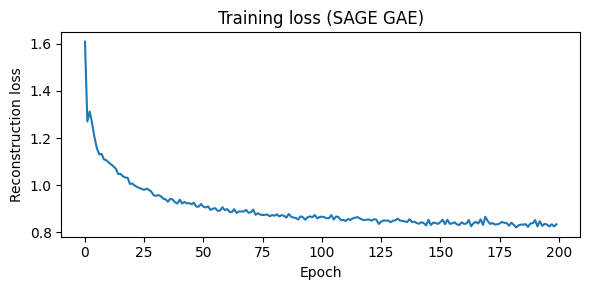

In [ ]:
EPOCHS = 200
model.train()
losses = []
for epoch in range(1, EPOCHS+1):
    optimizer.zero_grad()
    z = model.encode(data.x, data.edge_index)
    loss = model.recon_loss(z, data.edge_index, data.num_nodes)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | loss = {loss.item():.4f}")

plt.figure(figsize=(6,3))
plt.plot(losses)
plt.title(f"Training loss ({ENCODER_TYPE.upper()} GAE)")
plt.xlabel("Epoch"); plt.ylabel("Reconstruction loss")
plt.tight_layout(); plt.show()


## 8. Station & Link Anomaly Scoring

Dua jenis anomali dihitung dari model yang sudah dilatih:

1. **Station anomaly score** — kombinasi:
   - *Edge reconstruction error* rata-rata: seberapa buruk model memprediksi edge nyata suatu stasiun (skor tinggi = topologinya "tidak biasa" dibanding embedding-nya).
   - *Isolation Forest* pada embedding laten `z` — mendeteksi stasiun yang embeddingnya jauh dari mayoritas (outlier representasi).
2. **Link anomaly score** — untuk setiap edge nyata, skor = `1 - sigmoid(decode(z_u, z_v))`, yaitu seberapa "tak terduga" keberadaan link tsb menurut model (link yang menghubungkan dua stasiun yang embeddingnya sangat berbeda/tidak biasa → skor tinggi, kandidat link/interferensi yang perlu diverifikasi).


In [ ]:
model.eval()
with torch.no_grad():
    z = model.encode(data.x, data.edge_index)

    # --- link anomaly score (per directed edge -> ambil rata2 per pasangan unik) ---
    edge_scores = torch.sigmoid(model.decode(z, data.edge_index)).cpu().numpy()
    recon_err = 1.0 - edge_scores  # makin besar -> makin tidak terduga

# rata-rata reconstruction error per node (dari semua edge yg menyentuhnya)
node_recon_err = np.zeros(data.num_nodes)
node_edge_count = np.zeros(data.num_nodes)
src = data.edge_index[0].cpu().numpy()
for i, s in enumerate(src):
    node_recon_err[s] += recon_err[i]
    node_edge_count[s] += 1
node_edge_count[node_edge_count == 0] = 1
node_recon_err = node_recon_err / node_edge_count

# Isolation Forest pada embedding
iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=SEED)
iso_scores = -iso.fit_predict(z.cpu().numpy())  # 1=anomali(-1->1), -1=normal(1->-1) -> jadi 1/-1... ubah ke skor kontinu
iso_raw = -iso.decision_function(z.cpu().numpy())  # makin besar -> makin anomali

# Gabungkan skor (min-max normalize lalu rata-rata)
def minmax(a):
    a = np.asarray(a, dtype=float)
    return (a - a.min()) / (a.max() - a.min() + 1e-9)

station_anomaly_score = 0.5 * minmax(node_recon_err) + 0.5 * minmax(iso_raw)

node_df["recon_error"] = node_recon_err
node_df["isolation_forest_score"] = iso_raw
node_df["anomaly_score"] = station_anomaly_score

TOP_PCT = 0.05
threshold = node_df["anomaly_score"].quantile(1 - TOP_PCT)
node_df["is_anomaly"] = node_df["anomaly_score"] >= threshold

print(f"Threshold top {int(TOP_PCT*100)}%: {threshold:.4f}")
print(f"Jumlah stasiun teridentifikasi anomali: {node_df['is_anomaly'].sum()} dari {len(node_df)}")
node_df.sort_values("anomaly_score", ascending=False)[
    ["station_key","stn_name","clnt_name","service","freq_mean","erp_mean","anomaly_score","is_anomaly"]
].head(15)


Threshold top 5%: 0.3789
Jumlah stasiun teridentifikasi anomali: 57 dari 1125


,station_key,stn_name,clnt_name,service,freq_mean,erp_mean,anomaly_score,is_anomaly
1013,C1269_S4,REPEATER BI D.I YOGYAKARTA,BANK INDONESIA,LAND MOBILE (PRIVATE),167.650000,48.53213,0.554453,True
602,C113071_S2,HT. 01 - 40 BERGERAK SEKITAR SUROLOYO SAMIGALU...,"LINTAS DATA PRIMA, PT.",LAND MOBILE (PRIVATE),155.375000,36.98970,0.553637,True
4,C100777_S1,001/REPEATER HOTEL MELIA PUROSANI,"PUROSANI SRI PERSADA, PT.(HOTEL MELIA PUROSANI...",LAND MOBILE (PRIVATE),350.225000,55.02060,0.532772,True
653,C114358_S2,HT. 01 - 40 BERGERAK SEKITAR KECAMATAN LENDAH,CV. WIDYA HADIWINATA,LAND MOBILE (PRIVATE),167.325000,36.98970,0.518661,True
761,C117865_S1,REP. PAKUMAS MANDIRI,CV. PAKUMAS MANDIRI,LAND MOBILE (PRIVATE),355.600000,48.02060,0.518253,True
270,C106161_S1,REP. TAMAN WISATA RATU BOKO,"TAMAN WISATA CANDI BOROBUDUR, PT.",LAND MOBILE (PRIVATE),168.175000,48.02060,0.500003,True
762,C117865_S2,HT. 01-40 BERGERAK SEKITAR PAKUMAS MANDIRI,CV. PAKUMAS MANDIRI,LAND MOBILE (PRIVATE),350.600000,36.98970,0.497746,True
28,C101197_S1,HT. 01 HYPERMART HARTONO MALL JOGJA,MATAHARI PUTRA PRIMA,LAND MOBILE (PRIVATE),168.091667,36.98980,0.495966,True
29,C101197_S2,HT. 02-10 HYPERMART HARTONO MALL JOGJA,MATAHARI PUTRA PRIMA,LAND MOBILE (PRIVATE),168.091667,36.98980,0.495966,True
601,C113071_S1,REP. SUROLOYO SAMIGALUH,"LINTAS DATA PRIMA, PT.",LAND MOBILE (PRIVATE),160.425000,48.02060,0.491816,True


In [ ]:
# --- Link-level anomaly table (edge unik, ambil arah pertama saja) ---
seen = set()
link_records = []
dst = data.edge_index[1].cpu().numpy()
for i in range(len(src)):
    a, b = src[i], dst[i]
    key = tuple(sorted((int(a), int(b))))
    if key in seen:
        continue
    seen.add(key)
    ua, ub = node_ids[a], node_ids[b]
    link_records.append({
        "station_a": node_df.loc[a, "station_key"],
        "station_b": node_df.loc[b, "station_key"],
        "service_a": node_df.loc[a, "service"],
        "service_b": node_df.loc[b, "service"],
        "edge_type": G[ua][ub].get("edge_type"),
        "distance_km": haversine((G.nodes[ua]["lat"],G.nodes[ua]["lon"]),
                                  (G.nodes[ub]["lat"],G.nodes[ub]["lon"]), unit=Unit.KILOMETERS),
        "freq_diff_mhz": abs(G.nodes[ua]["freq_mean"] - G.nodes[ub]["freq_mean"]),
        "link_anomaly_score": float(recon_err[i]),
    })

link_df = pd.DataFrame(link_records).sort_values("link_anomaly_score", ascending=False)
print(f"Total edge unik: {len(link_df)}")
link_df.head(15)


Total edge unik: 5343


,station_a,station_b,service_a,service_b,edge_type,distance_km,freq_diff_mhz,link_anomaly_score
4928,C121419_S1,C121419_S2,LAND MOBILE (PRIVATE),LAND MOBILE (PRIVATE),link,0.000000,4.000,0.538106
5328,C3915_S1,C3915_S2,LAND MOBILE (PRIVATE),LAND MOBILE (PRIVATE),link,0.000000,4.000,0.519033
4424,C115111_S1,C115111_S2,LAND MOBILE (PRIVATE),LAND MOBILE (PRIVATE),link,0.000000,4.900,0.475631
4218,C113071_S1,C113071_S2,LAND MOBILE (PRIVATE),LAND MOBILE (PRIVATE),link,0.000000,5.050,0.453095
18,C100777_S1,C100777_S2,LAND MOBILE (PRIVATE),LAND MOBILE (PRIVATE),link,0.000000,5.000,0.452561
3445,C110825_S1,C110825_S2,LAND MOBILE (PRIVATE),LAND MOBILE (PRIVATE),link,0.000000,5.000,0.450431
754,C103494_S17,C113071_S1,LAND MOBILE (PRIVATE),LAND MOBILE (PRIVATE),interference_risk,14.961682,0.440,0.446436
25,C100777_S2,C117865_S1,LAND MOBILE (PRIVATE),LAND MOBILE (PRIVATE),interference_risk,13.967535,0.375,0.446246
4156,C112674_S1,C113279_S1,LAND MOBILE (PRIVATE),LAND MOBILE (PRIVATE),interference_risk,14.657459,0.025,0.442103
3309,C110254_S1,C110254_S2,LAND MOBILE (PRIVATE),LAND MOBILE (PRIVATE),link,0.000000,5.000,0.420155


## 9. Visualisasi GIS (Folium)

Peta interaktif:
- **Marker biru** = stasiun normal
- **Marker merah** = stasiun teridentifikasi anomali (top 5%), ukuran/ketebalan sebanding dengan `anomaly_score`
- **Garis** = edge graph (biru tipis = link eksplisit P-P, oranye putus-putus = potensi interferensi), garis merah tebal = edge dengan `link_anomaly_score` tertinggi


In [ ]:
center_lat, center_lon = node_df["lat"].mean(), node_df["lon"].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=9, tiles="cartodbpositron")

# Edges
TOP_LINK_ANOMALY_N = 20
top_anomalous_links = set(
    tuple(sorted((r["station_a"], r["station_b"])))
    for _, r in link_df.head(TOP_LINK_ANOMALY_N).iterrows()
)

node_lookup = node_df.set_index("station_key")[["lat","lon"]].to_dict("index")

for _, row in link_df.iterrows():
    a, b = row["station_a"], row["station_b"]
    if a not in node_lookup or b not in node_lookup:
        continue
    p1 = (node_lookup[a]["lat"], node_lookup[a]["lon"])
    p2 = (node_lookup[b]["lat"], node_lookup[b]["lon"])
    key = tuple(sorted((a,b)))
    if key in top_anomalous_links:
        color, weight, dash = "red", 3, None
    elif "link" in str(row["edge_type"]):
        color, weight, dash = "blue", 1.5, None
    else:
        color, weight, dash = "orange", 1, "5,5"
    folium.PolyLine([p1,p2], color=color, weight=weight, opacity=0.6,
                     dash_array=dash).add_to(m)

# Nodes
cluster = MarkerCluster().add_to(m)
for _, row in node_df.iterrows():
    is_anom = row["is_anomaly"]
    color = "red" if is_anom else "blue"
    radius = 6 + 10 * row["anomaly_score"] if is_anom else 4
    popup = folium.Popup(
        f"<b>{row['stn_name']}</b><br>Klien: {row['clnt_name']}<br>"
        f"Layanan: {row['service']} / {row['subservice']}<br>"
        f"Freq rata2: {row['freq_mean']:.2f} MHz (n_channel={int(row['n_channels'])})<br>"
        f"ERP rata2: {row['erp_mean']:.2f} dBm<br>"
        f"Anomaly score: {row['anomaly_score']:.3f}",
        max_width=300
    )
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=radius, color=color, fill=True, fill_opacity=0.75,
        popup=popup,
    ).add_to(cluster)

m.save("spectrum_intelligence_map.html")
print("Peta disimpan: spectrum_intelligence_map.html")
m


Peta disimpan: spectrum_intelligence_map.html


## 10. Ekspor Hasil

In [ ]:
node_df.to_csv("station_anomaly_scores.csv", index=False)
link_df.to_csv("link_anomaly_scores.csv", index=False)
nx.write_graphml(G, "station_graph.graphml")

print("File tersimpan:")
print(" - station_anomaly_scores.csv  (skor anomali per stasiun)")
print(" - link_anomaly_scores.csv     (skor anomali per link/edge)")
print(" - station_graph.graphml       (graph lengkap, bisa dibuka di Gephi)")
print(" - spectrum_intelligence_map.html (peta GIS interaktif)")

try:
    from google.colab import files as gfiles
    for f in ["station_anomaly_scores.csv","link_anomaly_scores.csv",
              "station_graph.graphml","spectrum_intelligence_map.html"]:
        gfiles.download(f)
except ImportError:
    pass


File tersimpan:
 - station_anomaly_scores.csv  (skor anomali per stasiun)
 - link_anomaly_scores.csv     (skor anomali per link/edge)
 - station_graph.graphml       (graph lengkap, bisa dibuka di Gephi)
 - spectrum_intelligence_map.html (peta GIS interaktif)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Catatan Pengembangan Lanjutan

- **Kalibrasi threshold**: `EPS_METERS`, `MAX_DIST_KM`, `FREQ_GUARD_MHZ`, dan `TOP_PCT` sebaiknya dikalibrasi memakai data ISR terverifikasi Balmon Yogyakarta (mis. mengacu ke tabel kanalisasi Kepmen Komdigi per `SERVICE`/`ZONA`).
- **Fitur tambahan**: `AZIM`/`ELEV_ANGLE` (arah antena) bisa dipakai untuk menghitung *beam alignment score* antar pasangan link P-P — berguna untuk mendeteksi anomali orientasi antena.
- **Validasi silang**: hasil `is_anomaly` dapat dicocokkan dengan hasil deteksi transmiter ilegal dari notebook sebelumnya (unsupervised anomaly detection SIMS) sebagai bentuk *ensemble validation*.
- **Skalabilitas**: untuk dataset nasional/multi-Balmon, ganti DBSCAN brute-force pairwise pada langkah interferensi dengan `sklearn.neighbors.BallTree` (haversine) agar tidak O(n²) per grup service besar.
- **GAT vs GraphSAGE**: ganti `ENCODER_TYPE = "gat"` untuk membandingkan performa — GAT memberi bobot atensi antar tetangga (berguna bila kepadatan interferensi sangat bervariasi antar node), sedangkan GraphSAGE lebih ringan dan stabil untuk graph besar.
